# Lab 03-1 - DBSCAN Clustering

In this lab we will transition towards focusing on machine learning methods themselves and away from the inner working of Python, `numpy`, and `pandas`. You should be prepared to use information from previous labs, but also to use published documentation to learn about useful functions, methods, and attributes on your own.

In [32]:
## Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

Examples throughout the lab will use the "moons" and "blobs" toy data sets that were introduced in a previous lab:

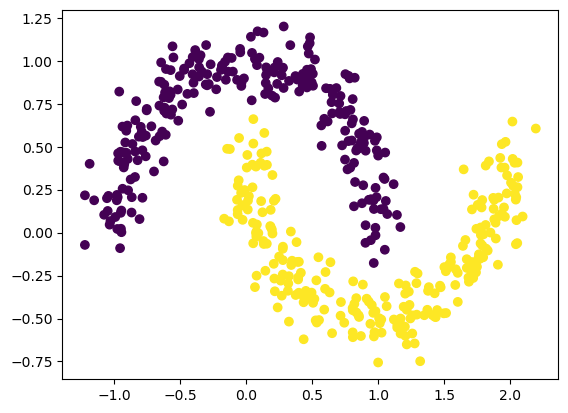

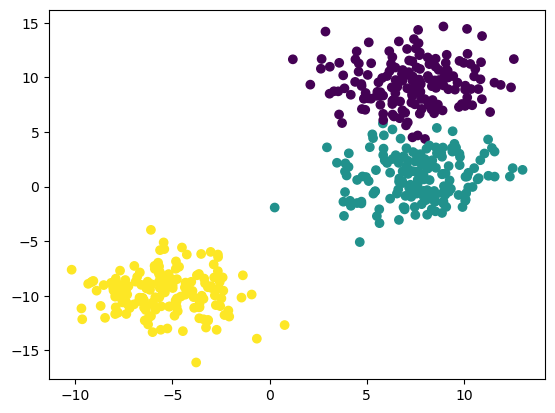

In [2]:
## Datasets module
from sklearn import datasets

## Toy Dataset #1 - "moons"
moons = datasets.make_moons(n_samples=500, noise=0.11, random_state=8)
moons_X = moons[0]         # features to use in clustering
moons_labels = moons[1]    # true cluster identities
## Visualization
plt.scatter(moons_X[:,0], moons_X[:,1], c =moons_labels)
plt.show()

## Toy Dataset #2 - "blobs"
blobs = datasets.make_blobs(n_samples=500, cluster_std=2, random_state=8)
blobs_X = blobs[0]         # features to use in clustering
blobs_labels = blobs[1]    # true cluster identities
## Visualization
plt.scatter(blobs_X[:,0], blobs_X[:,1], c = blobs_labels)
plt.show()

As with $k$-means, DBSCAN relies on distances between points, so we first standardize the "moons" features:

In [3]:
from sklearn.preprocessing import StandardScaler
moons_XS = StandardScaler().fit_transform(moons_X) 

## Part 1 - DBSCAN Clustering

In this section we'll demonstrate DBSCAN clustering using the "moons" data. The code below fits DBSCAN clusters to these data using the default arguments:

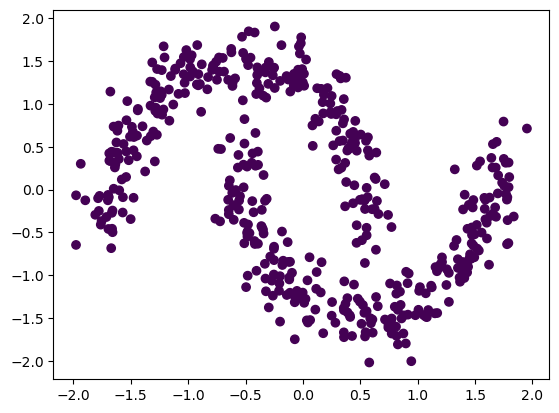

In [4]:
from sklearn.cluster import DBSCAN
results_dbscan = DBSCAN().fit(moons_XS)
plt.scatter(moons_XS[:,0], moons_XS[:,1], c = results_dbscan.labels_)
plt.show()

We see that the default values of `eps` and `min_samples` are way too large for our data, as they group all of the data into the same cluster. We can try some smaller values:

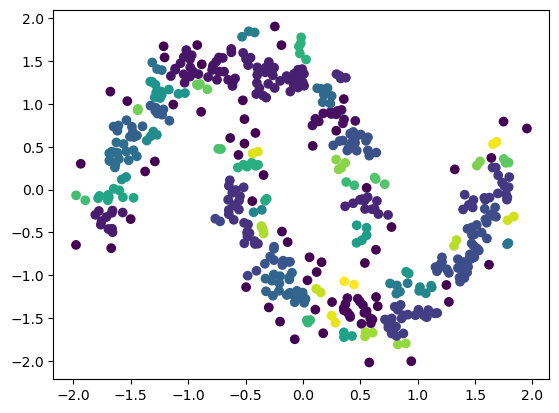

In [5]:
results_dbscan = DBSCAN(eps=0.1, min_samples=2).fit(moons_XS)
plt.scatter(moons_XS[:,0], moons_XS[:,1], c = results_dbscan.labels_)
plt.show()

This time we see that our hyperparameter choices are too small. For a simple data set like "moons" we can manually tune them through trial and error to get some really nice looking results:

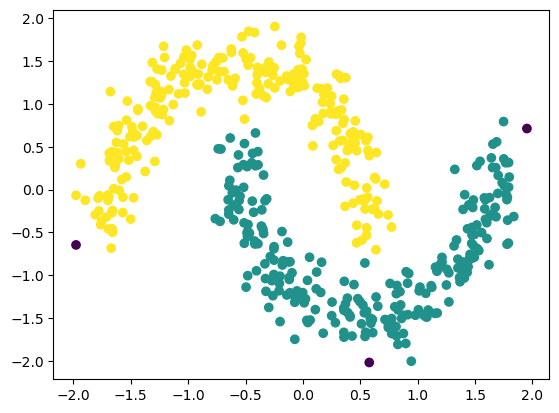

In [6]:
results_dbscan = DBSCAN(eps=0.28, min_samples=10).fit(moons_XS)
plt.scatter(moons_XS[:,0], moons_XS[:,1], c = results_dbscan.labels_)
plt.show()

We notice that we were able to get a reasonable fit with 3 detected outliers. We can find out the index positions of these outliers:

In [7]:
## Find predicted assignments
outliers_dbscan = DBSCAN(eps=0.28, min_samples=10).fit_predict(moons_XS)

## Outliers are denoted by the label '-1', so we can see that 0.6% of the 
## data were deemed outliers
# Count the number of outliers, then divide by number of points:
np.sum(outliers_dbscan == -1)/outliers_dbscan.shape[0]

np.float64(0.006)

**Question 1**:

The provided starter code includes

1. A function `run_DBSCAN()` that accepts the inputs: `eps`, `min_samples`, `data` and applies DBSCAN clustering to data using the given parameters. The function returns the percentage of data that was deemed to be an outlier for that combination of parameters.
1. A *search_grid* of values of `eps` to consider. It uses looping and the function above to explore a sequence of parameter values to find a combination of parameters that identifies percentage of the "moons" data set identified as outliers. 

Using this starter code:

- **Part A**: Find values of (`eps`, `min_samples`) such that 1% of values are identified as outliers. In this case, you will hold `min_samples=10`, but search over different values of `eps`. Note that you could also do the opposite: hold `eps` constant, and search over different values of `min_samples`
- **Part B**: Using `min_samples=10` and the value of `eps` you found in Part A, display a scatter plot of the resulting DBSCAN cluster assignments.

In [8]:
# Starter code of function
def run_DBSCAN(eps, min_samples, data):
    results_dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(data)
    return np.sum(results_dbscan == -1)/results_dbscan.shape[0]

# Test it by comparing to the previous results: should be 0.6%
run_DBSCAN(eps = 0.28, min_samples = 10, data = moons_XS)

np.float64(0.006)

In [ ]:
# Starter code of search grid
search_grid = np.linspace(start = 0.01, stop = 2, num = 10)
prop_outliers = np.zeros(search_grid.shape[0])

for i in range(search_grid.shape[0]):
    prop_outliers[i] = run_DBSCAN(eps = search_grid[i], min_samples = 10, data = moons_XS)
    print(f"eps = {search_grid[i]:.5f} -> {prop_outliers[i]:.1%} outliers")

eps = 0.01000 -> 100.0% outliers
eps = 0.23111 -> 4.8% outliers
eps = 0.45222 -> 0.0% outliers
eps = 0.67333 -> 0.0% outliers
eps = 0.89444 -> 0.0% outliers
eps = 1.11556 -> 0.0% outliers
eps = 1.33667 -> 0.0% outliers
eps = 1.55778 -> 0.0% outliers
eps = 1.77889 -> 0.0% outliers
eps = 2.00000 -> 0.0% outliers


In [13]:
# Starter code of search grid
search_grid = np.linspace(start = 0.2, stop = 0.3, num = 10)
prop_outliers = np.zeros(search_grid.shape[0])

for i in range(search_grid.shape[0]):
    prop_outliers[i] = run_DBSCAN(eps = search_grid[i], min_samples = 10, data = moons_XS)
    print(f"eps = {search_grid[i]:.5f} -> {prop_outliers[i]:.1%} outliers")

eps = 0.20000 -> 7.6% outliers
eps = 0.21111 -> 5.6% outliers
eps = 0.22222 -> 5.2% outliers
eps = 0.23333 -> 4.2% outliers
eps = 0.24444 -> 2.8% outliers
eps = 0.25556 -> 2.4% outliers
eps = 0.26667 -> 1.6% outliers
eps = 0.27778 -> 1.0% outliers
eps = 0.28889 -> 0.6% outliers
eps = 0.30000 -> 0.6% outliers


In [14]:
run_DBSCAN(eps = 0.27778, min_samples = 10, data = moons_XS)

np.float64(0.01)

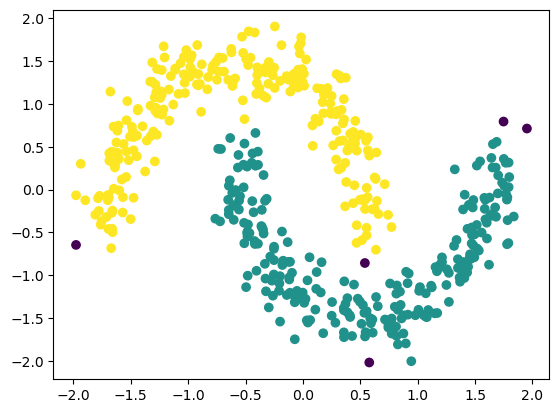

In [15]:
results_dbscan = DBSCAN(eps = 0.27778, min_samples = 10).fit(moons_XS)
plt.scatter(moons_XS[:,0], moons_XS[:,1], c = results_dbscan.labels_)
plt.show()

## Part 2 - Application

**Question 2**:

Your task in this portion of the lab is to apply your knowledge of clustering to analyze data that describe the workforce characteristics of college degree holders in a variety of fields. Let's start with some exploratory data analysis (EDA). 


In [16]:
jobs = pd.read_csv("../data/majors.csv")

# Look at first 10 rows of the raw data
jobs.head(n = 10)

,Major,Category,Workforce,Per_Male,Per_Female,Age_25_34,Age_35_44,Age_45_54,Age_55_64,Per_White,...,Per_Other_Race,Per_Bachelors,Per_Masters,Per_Professional_Degree,Per_PhD,Per_Employed,Per_Unemployed,Per_Non_Labor,Bach_Med_Income,Grad_Med_Income
0,Computer Science,Science,1665000.0,75.1,24.9,30.9,29.5,21.4,18.1,49.6,...,4.7,67.4,28.1,1.6,2.8,88.2,2.0,9.8,101600.0,128800.0
1,Engineering,Science,695400.0,81.3,18.7,24.1,26.1,25.3,24.4,53.9,...,4.6,61.0,31.3,4.0,3.8,87.8,1.9,10.3,90490.0,116100.0
2,Civil Engineering,Science,556200.0,77.7,22.3,29.7,25.8,22.3,22.1,62.1,...,4.2,63.9,29.7,2.6,3.8,89.8,1.4,8.8,94370.0,107500.0
3,Electrical Engineering,Science,1197000.0,84.5,15.5,22.5,26.3,23.7,27.5,47.1,...,4.0,53.2,37.2,2.9,6.7,88.5,1.7,9.8,106600.0,139400.0
4,Mechanical Engineering,Science,1033000.0,88.1,11.9,33.4,23.7,20.6,22.2,64.8,...,4.3,61.2,31.8,2.4,4.6,90.6,1.4,8.0,99180.0,124900.0
5,Mathmatics,Science,699900.0,57.0,43.0,27.2,24.5,22.8,25.4,65.4,...,4.7,48.5,38.6,4.8,8.1,85.4,1.7,12.9,76350.0,96530.0
6,Biology,Science,2201000.0,44.2,55.8,35.6,26.6,22.0,15.8,63.0,...,5.0,40.8,23.7,22.6,12.9,87.2,1.4,11.3,60390.0,102800.0
7,Chemistry,Science,613000.0,56.9,43.1,27.1,24.9,23.3,24.7,59.6,...,4.4,37.1,25.2,15.4,22.3,86.8,1.6,11.5,71060.0,109100.0
8,Psychology,Science,3075000.0,26.3,73.7,32.6,28.9,23.3,15.1,65.1,...,5.4,52.4,34.5,6.3,6.8,84.8,2.1,13.1,52460.0,72490.0
9,Economics,Science,1267000.0,64.9,35.1,28.0,26.1,22.1,23.9,62.2,...,4.5,58.6,29.1,8.5,3.8,85.5,2.4,12.1,89570.0,122100.0


In [17]:
# Additionally we can look at variable types, the amount of missing values (null count), $n$ = 34
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Major                    34 non-null     object 
 1   Category                 34 non-null     object 
 2   Workforce                34 non-null     float64
 3   Per_Male                 34 non-null     float64
 4   Per_Female               34 non-null     float64
 5   Age_25_34                34 non-null     float64
 6   Age_35_44                34 non-null     float64
 7   Age_45_54                34 non-null     float64
 8   Age_55_64                34 non-null     float64
 9   Per_White                34 non-null     float64
 10  Per_Black                34 non-null     float64
 11  Per_Asian                34 non-null     float64
 12  Per_Hispanic             34 non-null     float64
 13  Per_Other_Race           34 non-null     float64
 14  Per_Bachelors            34 

Your goal is to prepare a brief report that groups the workforce in different degree fields into clusters based upon commonalities, such as similar salaries, similar racial/ethnic/gender distributions, similar rates of graduate degree attainment, etc. You should explore at least two of the following clustering algorithms:

1. $k$-means clustering
1. agglomerative clustering
1. DBSCAN clustering

You should be careful to standardize the data if necessary and only cluster using variables you deem relevant to the analysis. You must:

1. Explain and justify all of your choices in a short "methods" paragraph, using graphs or numerical information as appropriate
1. Describe your final cluster assignments in a "results" paragraph, again using graphs or numerical information as appropriate.

This question is intentionally open-ended and is aimed at preparing you to use clustering methods on your own in the future. I encourage you to check-in with me if you ever feel unsure about what you've done.

I want to see what commonalities exist for  graduate degree attainment in the workforce. I used 3 features namely,Per_Masters, Per_Professional_Degree, Per_PhD and skipped Per_Bachelors. Since one requires a bachelor s degree to acquire the other three, I thought including it would double-count the same information. Masters, Professional Degrees and PhD attainment also behave differently for example, professional degrees dominate in health fields, so keeping them separate lets the clusters reflect that.

In [ ]:
#make a copy of df
df = jobs.copy()


#define features to use for clustering

features = ['Per_Masters', 'Per_Professional_Degree', 'Per_PhD']

#rescale each feature to mean 0 and standard deviation 1, this ensures no variable dominates just because of its units.
X = StandardScaler().fit_transform(df[features])


34

In [ ]:
from sklearn.cluster import DBSCAN

search_grid = np.linspace(0.3, 2, 18)     


for eps in search_grid:
    labels = DBSCAN(eps=eps, min_samples = 4).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    prop_out = np.mean(labels == -1)
    print(f"eps = {eps:.2f} -> {n_clusters} clusters, {prop_out:.1%} outliers")

From the search grid I picked eps = 0.80 because it sits at the start of a plateau. Outliers drop steeply from 82% to 12% as eps goes from 0.30 to 0.80, then flatten at 11.8% for 0.80 to 1.00. 
It is also the largest cluster count with a stable outlier rate. 0.70 also gives 3 clusters, but with 17.6% noise, so 0.80 is the first eps where you get 3 clusters while discarding only 4 points from the data, since we only have 34 points, its important to minimise this.

In [ ]:
db = DBSCAN(eps=0.8, min_samples=4).fit(X)  
df["dbscan"] = db.labels_

print(df["dbscan"].value_counts())
print(df.groupby("dbscan")["Major"].apply(list))
print(df.groupby("dbscan")[features].mean().round(2))

In [46]:
#Calculate the silhouette score to estimate the optimal number of clusters

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score


for k in range(2, 9):
    lab = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    score = silhouette_score(X, lab)
    print(f"Number of clusters: {k}, Silhouette Score: {score}")


Number of clusters: 2, Silhouette Score: 0.6010958525128571
Number of clusters: 3, Silhouette Score: 0.344076147974451
Number of clusters: 4, Silhouette Score: 0.37488119931349584
Number of clusters: 5, Silhouette Score: 0.36819444251515054
Number of clusters: 6, Silhouette Score: 0.3889231086300711
Number of clusters: 7, Silhouette Score: 0.3948880404429156
Number of clusters: 8, Silhouette Score: 0.3776238475239205


In [ ]:

for k in [2, 4]:
    df[f"agg{k}"] = AgglomerativeClustering(
        n_clusters=k, 
        linkage="ward").fit_predict(X)
    
    print(f"\nk={k} sizes:\n", df[f"agg{k}"].value_counts().sort_index())
    print(df.groupby(f"agg{k}")[features].mean().round(1))
    print(df.groupby(f"agg{k}")["Major"].apply(list).to_string())


k=2 sizes:
 agg2
0    31
1     3
Name: count, dtype: int64
      Per_Masters  Per_Professional_Degree  Per_PhD
agg2                                               
0            28.1                      4.3      3.2
1            25.1                     19.9     13.2
agg2
0    [Computer Science , Engineering , Civil Engineering , Electrical Engineering , Mechanical Engineering , Mathmatics, Psychology , Economics , Sociology , Nursing , Other Science, General Business , Accounting , Business Adminstration , Marketing , Finance , Other Business , General Education, Elementary Education, Other Education, Communications , English Language and Literature , Liberal Arts , History , Fine Arts , Commerical Art and Graphic Design , Family and Consumer Sciences , Fitness and Recreation, Criminal Justice and Fire Protection, Social Work , Other Humanities ]
1                                                                                                                                           

Silhouette scores peaked at k=2 (0.60), but that solution isolates only three majors; scores for k=3 to 8 were similar (0.34 to 0.39), so I used k=4 (0.375), which yields interpretable groups and allows direct comparison with DBSCAN.

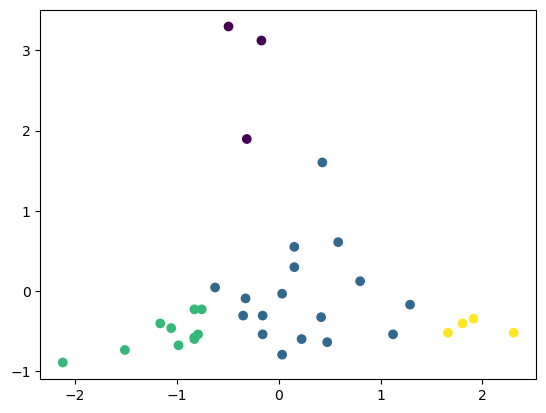

In [52]:
agg_cluster_ward_grad = AgglomerativeClustering(
    linkage = 'ward',
    n_clusters = 4).fit_predict(X)
agg_cluster_ward_grad
plt.scatter(X[:,0],X[:,1],c=agg_cluster_ward_grad)
plt.show()

In [53]:
print(df.groupby("agg4")[features].mean().round(1))
print(pd.crosstab(df["agg4"], df["dbscan"]))
print("k=4 silhouette:", round(silhouette_score(X, df["agg4"]), 3))

      Per_Masters  Per_Professional_Degree  Per_PhD
agg4                                               
0            25.1                     19.9     13.2
1            29.8                      5.3      4.4
2            18.7                      2.9      1.5
3            43.9                      3.4      2.4
dbscan  -1   0   1   2
agg4                  
0        3   0   0   0
1        1  11   5   0
2        0  10   0   0
3        0   0   0   4
k=4 silhouette: 0.375


Ward agglomerative clustering (k = 4, silhouette = 0.375) and DBSCAN (eps = 0.8, min_samples = 4) showed relatively similar resulst. Ward's first cluster (n = 3: Biology, Chemistry, Political Science) has the highest professional-degree (19.9%) and PhD (13.2%) rates, with master's attainment (25.1%) near the overall average. The second cluster (n = 17) contains most STEM and engineering fields plus Economics, Sociology, Psychology, Accounting, Finance, English and History. These fields have higher master's attainment (29.8%) and low professional (5.3%) and PhD (4.4%) rates. The third cluster (n = 10), which includes Nursing, most business majors, Communications, Liberal Arts, Fine Arts, Graphic Design, and Criminal Justice, has the lowest graduate attainment on every measure (master's 18.7%, professional 2.9%, PhD 1.5%). The fourth cluster (n = 4: General, Elementary, and Other Education, plus Social Work) is master's-dominated (43.9%), with few professional (3.4%) or PhD (2.4%) degrees. 
DBSCAN found three clusters (n = 21, 5, and 4) and four noise points (11.8%): Biology, Chemistry, Political Science, and History. The methods agree on the extremes. All four members of DBSCAN's Education and Social Work cluster form Ward's fourth cluster, and three of DBSCAN's four noise points form Ward's first cluster. They differ in two ways. History is noise under DBSCAN but falls in Ward's large second cluster, which suggests it is a borderline case (professional rate 13.9%). And Ward splits DBSCAN's 21-major cluster almost evenly (11 majors to Ward's second cluster, 10 to its third), along master's attainment, while DBSCAN treats them as one dense region. 
Overall, the two methods suggest that graduate attainment in these data differs by field: master's-driven fields (education, social work), professional- and PhD-heavy fields (biology, chemistry, political science), and a large middle group with modest attainment of all kinds.